# Guerras arancelarias: aranceles óptimos, represalias y una comprobación numérica de Nash

**¿Cómo acaba una guerra arancelaria entre dos países que fijan aranceles sin cooperar: dónde terminan los aranceles y quién gana?**

Esta economía de dos países, balanceada a mano, es sintética. Los países A y B son ilustrativos; no se predice ninguna política nacional real. Cada comparación de políticas usa la misma función de gasto de consumo, el mismo equilibrio de referencia con libre comercio y la misma contabilidad auditada.

## El método en matemáticas

El país $i$ valora dos canastas de uso final $k\in\{0,2\}$; la inversión (categoría 1) queda fuera. Cada canasta es un conjunto Leontief fijo de bienes nacionales y extranjeros con precio de comprador $P_{ik}$, que incluye aranceles e impuestos sobre el uso final. Las canastas se combinan con una Cobb-Douglas con las participaciones de gasto calibradas $\theta_{ik}$:

$$U_i=\prod_{k\in\{0,2\}}c_{ik}^{\omega_{ik}},\qquad e_i(P,U)=U\prod_{k\in\{0,2\}}\Big(\frac{P_{ik}}{\omega_{ik}}\Big)^{\omega_{ik}},\qquad \omega_{ik}=\frac{\theta_{ik}}{\theta_{i0}+\theta_{i2}}.$$

Un perfil arancelario $\tau=(\tau_A,\tau_B)$ paga la variación equivalente a los precios de libre comercio $P_0$, expresada como proporción del gasto inicial en consumo $m_{i0}=e_i(P_0,U_{i0})$. La mejor respuesta recorre el intervalo declarado $[0,\bar\tau]$:

$$EV_i(\tau)=e_i\big(P_0,U_i(\tau)\big)-e_i(P_0,U_{i0}),\qquad BR_i(\tau_{-i})=\arg\max_{t\in[0,\bar\tau]}EV_i(t,\tau_{-i}).$$

Un equilibrio de Nash en $[0,\bar\tau]$ cumple $\tau_i=BR_i(\tau_{-i})$ para ambos jugadores. La búsqueda actualiza a los jugadores por turnos, $\tau_i\leftarrow(1-\lambda)\tau_i+\lambda\,BR_i(\tau_{-i})$ con relajación $\lambda$, y solo acepta un candidato si

$$\max_i|BR_i(\tau_{-i})-\tau_i|\leq\epsilon_\tau,\qquad \max_i r_i/m_{i0}\leq\epsilon_r,\qquad r_i=\max_{t\in[0,\bar\tau]}EV_i(t,\tau_{-i})-EV_i(\tau).$$

## Intuición

**Intuición.** Un arancel reduce el precio que un país paga a los exportadores extranjeros, de modo que el socio paga parte del arancel mediante peores términos de intercambio, y la recaudación se devuelve a los hogares nacionales. Frente a esta ganancia de términos de intercambio está una pérdida por sustitución: los compradores se alejan de las importaciones gravadas. El arancel óptimo de manual equilibra ambas y es igual a la inversa de la elasticidad de la oferta de exportaciones del socio: cuanto menos puede el socio redirigir sus exportaciones, mayor es el arancel. En este modelo, el trabajo y el capital fijos de cada país producen un único bien, y las canastas de uso final son Leontief entre orígenes. Por eso los hogares nunca sustituyen entre bienes nacionales y extranjeros, y las empresas sustituyen insumos intermedios solo con elasticidad sigma = 2. La pérdida por sustitución es demasiado pequeña para compensar la ganancia de términos de intercambio, así que el bienestar de cada país crece monótonamente con su propio arancel; el código lo comprueba hasta el 300%, con el socio en libre comercio o en el 30%. Por tanto, cada «arancel óptimo» y cada candidato de Nash que aparece a continuación es el límite que imponemos, no un óptimo interior. Las represalias deciden quién gana. Cuando ambos países imponen aranceles, los efectos de términos de intercambio se compensan en parte y el resultado depende de las asimetrías de la tabla. El dilema del prisionero, en el que los aranceles mutuos dejan a ambos peor que el libre comercio, es una propiedad que debe comprobarse en la matriz de pagos; las represalias por sí solas no lo implican. El pago solo cuenta el consumo, así que los recursos que los aranceles trasladan de la inversión al consumo aparecen como ganancias.

## Código resuelto

Construimos una tabla de transacciones balanceada con un sector productor por país, dos canastas de consumo (categorías 0 y 2), una categoría de inversión separada (1), impuestos domésticos y saldos externos no nulos. El trabajo y el capital se reparten el valor agregado residual de cada sector en proporción 2/3 : 1/3 y cierran las cuentas de producción; en el modelo, las dotaciones de factores son fijas y los salarios y las rentas son endógenos. El ahorro externo se fija como proporción del ingreso factorial mundial (`foreign_saving_units="world_income"`), de modo que ningún precio nacional sirve de unidad de cuenta y los resultados no dependen de qué país aparece primero.

In [1]:
from pathlib import Path
from dataclasses import replace
import sys
import numpy as np
import matplotlib.pyplot as plt

repo = Path.cwd() if (Path.cwd() / "puremacro").is_dir() else Path.cwd().parent
sys.path.insert(0, str(repo))
sys.path.insert(0, str(repo / "notebooks"))
import _nbstyle
_nbstyle.apply_style()
from puremacro.trade import (
    calibrate_trade_model, solve_policy_equilibrium, build_strategic_tariffs,
    compute_hicksian_welfare, compute_unilateral_optimal_tariff,
    compute_welfare_payoff_matrix, solve_multilateral_nash_tariffs,
)

# Columns: intermediate use in A/B, then final use C1/I/C2 in A and C1/I/C2 in B.
flows = np.array([[10., 12., 24., 8., 6., 4., 20., 16.],
                  [8., 14., 4.5, 15., 10.5, 35., 18., 15.]])
taxes = np.array([4., 6., 1.2, 1., .8, 1.8, 2., 1.2])
value_added = flows.sum(1) - flows[:, :2].sum(0) - taxes[:2]
data = np.vstack([flows, taxes, np.r_[2*value_added/3, np.zeros(6)],
                  np.r_[value_added/3, np.zeros(6)]])
calib = calibrate_trade_model(data, ns=1, nc=2, nfd=3, country_codes=["A", "B"])
calib = replace(calib, metadata={**calib.metadata, "is_synthetic": True,
    "source": "hand-balanced teaching table", "unit": "illustrative value units"})
players = tuple(calib.country_codes)
print(f"Imports at base prices: A buys {flows[1, [0, 2, 3, 4]].sum():g} units from B, "
      f"B buys {flows[0, [1, 5, 6, 7]].sum():g} units from A; foreign balances {calib.invforT.ravel()}")
closure = dict(sigma=2., foreign_saving_units="world_income")
base = solve_policy_equilibrium(calib, tol=1e-9, **closure)
options = dict(metric="hicksian_ev", consumption_categories=(0, 2),
               base_equilibrium=base, ge_tol=1e-9, **closure)

def ev_pct(eq):
    """Consumption EV of A and B, % of each country's baseline consumption."""
    return np.array([compute_hicksian_welfare(calib, eq, base_result=base, target_country=p,
                     consumption_categories=(0, 2)).ev_pct_consumption for p in players])

def solve_profile(profile, seed):
    ta, tf = build_strategic_tariffs(calib, profile)
    return solve_policy_equilibrium(calib, ta, tf, x0=seed, tol=1e-9, **closure)

Imports at base prices: A buys 38 units from B, B buys 52 units from A; foreign balances [ 14. -14.]


### Una búsqueda unilateral acotada

Seleccionamos explícitamente `metric="hicksian_ev"`. El país A elige un arancel universal a las importaciones en $[0, 30\%]$ mientras B mantiene el libre comercio. El modelo usa abastecimiento intermedio CES con sigma 2, canastas finales Leontief fijas y devolución de suma fija de todos los impuestos y aranceles. Los porcentajes dividen EV entre el gasto inicial en consumo. Después resolvemos la economía muy por encima del límite, hasta un arancel del 300%, con el socio en libre comercio o en el 30%. Las funciones auxiliares `solve_profile` y `ev_pct` llaman a las mismas funciones públicas que usan las búsquedas (`build_strategic_tariffs`, `solve_policy_equilibrium`, `compute_hicksian_welfare`).

In [2]:
tariff_ceiling = 0.30
opt = compute_unilateral_optimal_tariff(calib, country_idx="A", tariff_max=tariff_ceiling,
    num_grid=9, method="bounded", **options)
print(f"A's best tariff on [0, {tariff_ceiling:.0%}]: {opt.optimal_tariff_rate:.4f} "
      f"({opt.metadata['boundary']} bound), EV = {opt.welfare_gain_pct:+.2f}% of baseline consumption")
assert opt.metadata["boundary"] == "upper" and opt.optimal_tariff_rate == tariff_ceiling

# Own-tariff payoff far beyond the ceiling, partner at free trade or at the ceiling.
own_grid = np.r_[0., .1, .2, .3, .5, 1., 1.5, 2., 2.5, 3.]
curves = {}
for k, p in enumerate(players):
    for rival_rate in (0., tariff_ceiling):
        seed, values = base.x_sol, []
        for rate in own_grid:  # warm-start each solve from the previous tariff
            eq = solve_profile({p: float(rate), players[1-k]: rival_rate}, seed)
            seed = eq.x_sol
            values.append(ev_pct(eq)[k])
        curves[p, rival_rate] = np.array(values)
        print(f"{p}, partner at {rival_rate:.0%}: EV at own tariff 30% / 100% / 300% = "
              f"{values[3]:+.2f}% / {values[5]:+.2f}% / {values[9]:+.2f}%")
# Internal consistency: the helper route reproduces the search's payoff at the ceiling.
assert abs(curves["A", 0.][3] - opt.welfare_gain_pct) < 1e-6
assert all(np.all(np.diff(c) > 0) for c in curves.values())  # no interior optimum up to 300%

A's best tariff on [0, 30%]: 0.3000 (upper bound), EV = +7.07% of baseline consumption
A, partner at 0%: EV at own tariff 30% / 100% / 300% = +7.07% / +18.94% / +37.14%


A, partner at 30%: EV at own tariff 30% / 100% / 300% = -3.17% / +7.70% / +25.42%
B, partner at 0%: EV at own tariff 30% / 100% / 300% = +11.69% / +27.80% / +46.79%


B, partner at 30%: EV at own tariff 30% / 100% / 300% = +6.27% / +23.26% / +44.29%


### Un juego arancelario con acciones fijas

Cada jugador elige libre comercio (0%) o su propio óptimo unilateral en $[0, 30\%]$, que la biblioteca calcula cuando no se le indica ninguna acción; para ambos países es el límite del 30%. Cada celda muestra (EV % de A, EV % de B), cada uno respecto al consumo inicial de su país. Un dilema del prisionero exige un arancel estrictamente dominante para ambos jugadores y que los aranceles mutuos dejen a ambos peor que el libre comercio. Después reconstruimos el mismo juego con B en primer lugar; con el ahorro externo ligado al ingreso mundial, los pagos no deben cambiar.

In [3]:
payoffs = compute_welfare_payoff_matrix(calib, player_a="A", player_b="B",
    tariff_max=tariff_ceiling, num_grid=9, **options)
M = payoffs.payoff_matrix  # M[i, j, k]: EV % of player k when A plays i and B plays j (1 = tariff)
actions = payoffs.metadata["action_tariffs"]
print("Positive actions:", {p: f"{t:.0%}" for p, t in actions.items()})
print(payoffs.summary())
dominant = {"A": bool(M[1, 0, 0] > M[0, 0, 0] and M[1, 1, 0] > M[0, 1, 0]),
            "B": bool(M[0, 1, 1] > M[0, 0, 1] and M[1, 1, 1] > M[1, 0, 1])}
print("Tariff strictly dominant:", dominant)
print(f"Mutual tariffs vs free trade: A {M[1, 1, 0]:+.2f}%, B {M[1, 1, 1]:+.2f}%")
print("Prisoner's Dilemma?", payoffs.is_prisoners_dilemma)
assert all(dominant.values()) and M[1, 1, 0] < 0 < M[1, 1, 1]
assert payoffs.is_prisoners_dilemma is False  # fails only through B, who gains from the war

# Relabel the table with B first: permute the producer rows and the country columns.
data_ba = data[:, [1, 0, 5, 6, 7, 2, 3, 4]]
data_ba[:2] = data_ba[[1, 0]]
calib_ba = calibrate_trade_model(data_ba, ns=1, nc=2, nfd=3, country_codes=["B", "A"])
base_ba = solve_policy_equilibrium(calib_ba, tol=1e-9, **closure)
payoffs_ba = compute_welfare_payoff_matrix(calib_ba, player_a="A", player_b="B",
    optimal_a=actions["A"], optimal_b=actions["B"], **{**options, "base_equilibrium": base_ba})
order_gap = np.abs(payoffs_ba.payoff_matrix - M).max()
print("Largest payoff change with B listed first is below 1e-8 percentage points:", order_gap < 1e-8)
assert order_gap < 1e-6

Positive actions: {'A': '30%', 'B': '30%'}
                       B: 0%                 B: 30%
A: 0%   (+0.0000%, +0.0000%)  (-9.4111%, +11.6937%)
A: 30%  (+7.0728%, -5.7883%)   (-3.1726%, +6.2667%)
Tariff strictly dominant: {'A': True, 'B': True}
Mutual tariffs vs free trade: A -3.17%, B +6.27%
Prisoner's Dilemma? False
Largest payoff change with B listed first is below 1e-8 percentage points: True


### Diagnósticos numéricos de mejores respuestas

El juego continuo permite a cada país elegir cualquier arancel en $[0, 30\%]$. Con relajación $\lambda=1$, cada barrido lleva cada arancel hasta su mejor respuesta; un $\lambda$ menor amortigua la actualización, lo que puede ayudar cuando las mejores respuestas se pasan de largo. La convergencia exige las dos pruebas en el perfil final: la brecha de mejores respuestas dentro de `tol` y la ganancia por desviarse de cada jugador dentro de `regret_tol` de su consumo inicial. Cada solución de equilibrio se audita: todas las ecuaciones de vaciado de mercados y de contabilidad se recalculan y deben cumplirse con `ge_tol`. Si el método de Newton falla, el solver prueba el método híbrido de Powell de SciPy y luego la continuación por pseudolongitud de arco (Keller), un método de seguimiento de trayectorias que se muestra en el cuaderno 64. Nunca relaja la tolerancia, y si todos los intentos fallan se produce un error. El resultado puede ser inconcluso; en ese caso debe comunicarse así. Tras la búsqueda valoramos el candidato: bienestar, términos de intercambio, EV de consumo mundial e inversión real.

In [4]:
nash = solve_multilateral_nash_tariffs(calib, player_countries=players,
    tariff_max=tariff_ceiling, best_response_grid_size=7, max_iter=20,
    relaxation=1., tol=1e-4, regret_tol=1e-6, **options)
last_ge = nash.equilibrium.metadata["policy_solver_attempts"][-1]
gaps = [h["undamped_update_gap"] for h in nash.iteration_history]
print("Candidate tariffs:", {p: round(t, 4) for p, t in nash.nash_tariffs.items()},
      "| best responses at bound:", nash.metadata["best_response_boundaries"])
print(f"Converged: {nash.converged} | best-response gap per sweep {gaps} | final gap "
      f"{nash.outer_error:.1e} (tol 1e-4) | relative regret {nash.metadata['relative_max_regret']:.1e} (tol 1e-6)")
print(f"Final GE solve: {last_ge['method']}, accepted {last_ge['accepted']}, "
      f"audited residual <= 1e-9: {last_ge['audited_max_residual'] <= 1e-9}")
print(nash.summary())
w, tot = nash.welfare_changes_pct, nash.terms_of_trade_changes_pct
investment = 100*(nash.equilibrium.c_fd[0, 1]/base.c_fd[0, 1] - 1)
at_base_prices = base.Pfd_final[0]*(nash.equilibrium.c_fd[0] - base.c_fd[0])  # (use, country)
print(f"World consumption EV {nash.world_welfare_change_pct:+.2f}% | real investment "
      f"A {investment[0]:+.2f}%, B {investment[1]:+.2f}%")
print(f"Change at baseline prices (value units): consumption {at_base_prices[[0, 2]].sum():+.2f}, "
      f"investment {at_base_prices[1].sum():+.2f}, all final demand {at_base_prices.sum():+.2f}")
assert nash.converged and set(nash.metadata["best_response_boundaries"].values()) == {"upper"}
# The best reply is the ceiling whatever the rival does: one sweep lands on it, the next confirms.
assert gaps == [tariff_ceiling, 0.]
assert w["A"] < 0 < w["B"] and tot["A"] < 0 < tot["B"]
assert nash.world_welfare_change_pct > 0 and np.all(investment < 0) and at_base_prices.sum() < 0

Candidate tariffs: {'A': 0.3, 'B': 0.3} | best responses at bound: {'A': 'upper', 'B': 'upper'}
Converged: True | best-response gap per sweep [0.3, 0.0] | final gap 0.0e+00 (tol 1e-4) | relative regret 0.0e+00 (tol 1e-6)
Final GE solve: newton, accepted True, audited residual <= 1e-9: True
       Nash_Tariff_% Welfare_Change_% Terms_of_Trade_Shift_%
Player                                                      
A             30.00%           -3.17%                 -7.87%
B             30.00%           +6.27%                 +8.54%
World consumption EV +2.57% | real investment A -9.66%, B -4.31%
Change at baseline prices (value units): consumption +3.29, investment -4.04, all final demand -0.75


Dos comprobaciones del candidato. Primero, una comprobación de consistencia interna (una segunda ruta dentro de puremacro, no un oráculo independiente): resolvemos la economía en 31 desviaciones equiespaciadas para cada jugador, con el rival en su arancel candidato, y confirmamos que ninguna desviación supera al candidato en más de `regret_tol`. Segundo, una búsqueda truncada a propósito, un solo barrido con relajación 0.0003, muestra por qué un paso amortiguado pequeño no es una prueba de convergencia.

In [5]:
for k, p in enumerate(players):
    seed, best = nash.equilibrium.x_sol, -np.inf
    for rate in np.linspace(0., tariff_ceiling, 31):
        eq = solve_profile({p: float(rate), players[1-k]: nash.nash_tariffs[players[1-k]]}, seed)
        seed, best = eq.x_sol, max(best, ev_pct(eq)[k])
    print(f"{p}: best of 31 deviations {best:+.4f}% vs candidate {w[p]:+.4f}%")
    assert (best - w[p])/100 <= 1e-6  # regret as a fraction of baseline consumption

short = solve_multilateral_nash_tariffs(calib, player_countries=players,
    tariff_max=tariff_ceiling, best_response_grid_size=7, max_iter=1,
    relaxation=3e-4, tol=1e-4, regret_tol=1e-6, **options)
step = short.iteration_history[-1]["step"]
print(f"Truncated search: step {step:.1e} (below tol 1e-4), gap {short.outer_error:.2f}, "
      f"relative regret {short.metadata['relative_max_regret']:.3f}, converged {short.converged}")
assert step < 1e-4 and not short.converged and short.metadata["relative_max_regret"] > 1e-2

A: best of 31 deviations -3.1726% vs candidate -3.1726%


B: best of 31 deviations +6.2667% vs candidate +6.2667%


Truncated search: step 9.0e-05 (below tol 1e-4), gap 0.30, relative regret 0.117, converged False


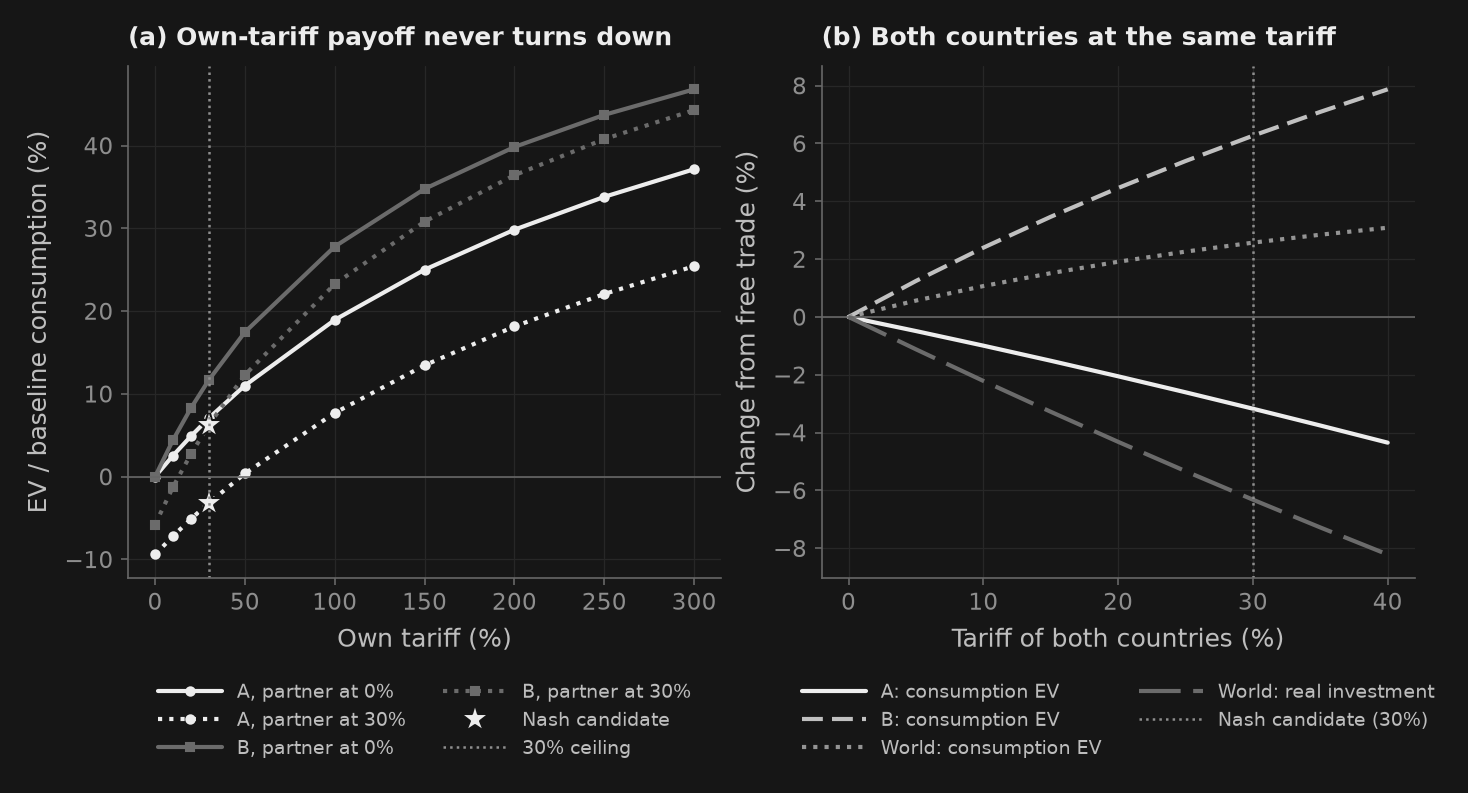

In [6]:
# Both countries at the same tariff t: for t = 30% this is the Nash candidate.
mutual = np.linspace(0., .4, 9)
m0 = opt.metadata["baseline_consumption_by_country"]  # baseline consumption spending
investment0 = base.Pfd_final[0, 1] @ base.c_fd[0, 1]
seed, war = base.x_sol, []
for t in mutual:
    eq = solve_profile({"A": float(t), "B": float(t)}, seed)
    seed, ev = eq.x_sol, ev_pct(eq)
    investment_t = base.Pfd_final[0, 1] @ eq.c_fd[0, 1]  # at baseline prices
    war.append([*ev, ev @ m0/m0.sum(), 100*(investment_t/investment0 - 1)])
war = np.array(war)
# Columns: EV of A, EV of B, world consumption EV, world real investment (all %).
assert np.all(np.diff(war, axis=0)*np.array([-1, 1, 1, -1]) > 0)

fig, axes = _nbstyle.figura(1, 2, alto=True)
ink = _nbstyle.palette(2)
# Lightness and marker tell the countries apart; solid vs dotted, the partner's tariff.
for (p, rival_rate), values in curves.items():
    axes[0].plot(100*own_grid, values, ls="-" if rival_rate == 0 else (0, (1, 1.7)),
                 marker="o" if p == "A" else "s", ms=4, color=ink[players.index(p)],
                 label=f"{p}, partner at {rival_rate:.0%}")
axes[0].plot([100*tariff_ceiling]*2, [w["A"], w["B"]], "*", ms=14, color=_nbstyle.TINTA,
             markeredgecolor=_nbstyle.FONDO, label="Nash candidate")
axes[0].set(title="(a) Own-tariff payoff never turns down", xlabel="Own tariff (%)",
            ylabel="EV / baseline consumption (%)")
for j, (label, ls) in enumerate([("A: consumption EV", "-"), ("B: consumption EV", (0, (5, 2.2))),
                                 ("World: consumption EV", (0, (1, 1.7))),
                                 ("World: real investment", (0, (10, 3)))]):
    axes[1].plot(100*mutual, war[:, j], ls=ls, color=_nbstyle.palette(4)[j], label=label)
axes[1].set(title="(b) Both countries at the same tariff", xlabel="Tariff of both countries (%)",
            ylabel="Change from free trade (%)")
for ax, note in zip(axes, ("30% ceiling", "Nash candidate (30%)")):
    ax.axvline(100*tariff_ceiling, color=_nbstyle.NOTA, ls=":", lw=1.2, label=note)
    ax.axhline(0, color=_nbstyle.SPINE, lw=0.8)
    ax.legend(fontsize=9, ncol=2, handlelength=3.4, loc="upper center", bbox_to_anchor=(0.5, -0.17))

## Lectura de los resultados

**Búsqueda unilateral.** El mejor arancel de A en $[0, 30\%]$ es el propio límite (0.3000, frontera superior), que vale +7.07% del consumo inicial. Las curvas impresas y el panel (a) muestran por qué el límite es activo: la EV de cada país sigue creciendo con su propio arancel hasta el 300%, tanto si el socio mantiene el libre comercio como si responde con un 30% (A llega a +37.14% y +25.42%, B a +46.79% y +44.29%). En esta calibración no existe un arancel óptimo finito, así que el «óptimo» reportado solo repite el límite que elegimos.

**Juego con acciones fijas.** Con el 30% como acción positiva de cada jugador, el arancel es estrictamente dominante para ambos: haga lo que haga el socio, un arancel aumenta la EV propia. Aun así, el juego no es un dilema del prisionero. Los aranceles mutuos dejan a A peor que el libre comercio (-3.17%) pero a B mejor (+6.27%), así que el libre comercio no domina en el sentido de Pareto a la guerra; la desigualdad que falla es la de B. Poner a B en primer lugar no cambia ningún pago, como garantiza el cierre con ingreso mundial.

**Candidato de Nash.** La búsqueda se detiene en (0.3, 0.3) con ambas mejores respuestas en la frontera superior: el candidato es el par de límites, no un equilibrio interior. Las brechas por barrido, [0.3, 0.0], dicen lo mismo: el primer barrido salta del libre comercio al límite, y el segundo encuentra las mismas mejores respuestas porque no dependen del arancel del rival. Ambas pruebas se cumplen con una brecha final y una ganancia relativa por desviarse de 0.0e+00, porque las mejores respuestas en el candidato son el propio candidato, y los barridos de 31 desviaciones no encuentran ninguna desviación que lo supere. La búsqueda truncada muestra por qué las pruebas miran la brecha de mejores respuestas y la ganancia por desviarse y no el paso: su paso (9.0e-05) está por debajo de `tol`, pero la brecha es 0.30 y una desviación ganaría 0.117 del consumo inicial, así que se reporta correctamente como no convergida.

**Quién gana la guerra.** La EV de B es +6.27% y la de A es -3.17%. Los términos de intercambio de B cambian +8.54% y los de A -7.87%: aranceles simétricos no se anulan en una economía asimétrica (por ejemplo, B importa 52 unidades de A mientras A importa 38 de B). La EV de consumo mundial es +2.57%, pero no es una ganancia de la guerra: la inversión real cambia -9.66% en A y -4.31% en B. A precios iniciales, el consumo cambia +3.29 unidades y la inversión -4.04, de modo que la demanda final total cambia -0.75 unidades. Una EV que solo cuenta el consumo registra como ganancia los recursos que salen de la inversión. El panel (b) repite la comparación para aranceles comunes de 0 a 40%: la pérdida de A, la ganancia de B, la «ganancia» de consumo mundial y la caída de la inversión crecen con el arancel. Las estrellas del panel (a) son los pagos de Nash, sobre las curvas punteadas «partner at 30%» con un arancel propio del 30%.

## Tu turno

Trata el límite como un arancel consolidado negociado en un acuerdo comercial. Antes de ejecutar, predice: ¿el candidato de Nash sigue en el límite?, ¿A está mejor o peor que en la guerra con el 30%? La celda comprueba la respuesta para cualquier límite en $[1\%, 40\%]$.

In [7]:
custom_ceiling = 0.10  # ← change this: a negotiated tariff binding in [0.01, 0.40]
assert 0.01 <= custom_ceiling <= 0.40
custom = solve_multilateral_nash_tariffs(calib, player_countries=players,
    tariff_max=custom_ceiling, best_response_grid_size=7, max_iter=20,
    relaxation=1., tol=1e-4, regret_tol=1e-6, **options)
wc = custom.welfare_changes_pct
print(f"Candidate at a {custom_ceiling:.0%} binding:", {p: round(t, 4) for p, t in custom.nash_tariffs.items()},
      "| bounds:", custom.metadata["best_response_boundaries"], "| converged:", custom.converged)
print(f"EV: A {wc['A']:+.2f}%, B {wc['B']:+.2f}%, world {custom.world_welfare_change_pct:+.2f}% "
      f"(30% war: A {w['A']:+.2f}%, B {w['B']:+.2f}%, world {nash.world_welfare_change_pct:+.2f}%)")
assert custom.converged and set(custom.metadata["best_response_boundaries"].values()) == {"upper"}
assert wc["A"] < 0 < wc["B"]  # no binding in the range makes both countries gain
if custom_ceiling < tariff_ceiling:  # a tighter binding helps A and costs B
    assert wc["A"] > w["A"] and wc["B"] < w["B"]
elif custom_ceiling > tariff_ceiling:
    assert wc["A"] < w["A"] and wc["B"] > w["B"]

Candidate at a 10% binding: {'A': 0.1, 'B': 0.1} | bounds: {'A': 'upper', 'B': 'upper'} | converged: True
EV: A -0.99%, B +2.40%, world +1.07% (30% war: A -3.17%, B +6.27%, world +2.57%)


**Ejercicios graduados.**

1. *Básico.* Prueba `custom_ceiling = 0.05` y después `0.40`, prediciendo antes la dirección. ¿Qué país presionaría por un límite más estricto en una negociación? ¿Algún límite del rango deja a ambos países mejor que el libre comercio? Las aserciones de la celda comprueban ambas respuestas.
2. *Intermedio: el cierre importa.* Reconstruye el juego con acciones fijas en ambos órdenes de países con `foreign_saving_units="numeraire"`, que fija el ahorro externo en unidades del precio del país que aparece primero. Predice cuáles de estos elementos dependen del orden: la magnitud de los pagos, sus signos, la acción dominante, el veredicto del dilema del prisionero.

   ```python
   games = {}
   for name, table, order in (("AB", data, ["A", "B"]), ("BA", data_ba, ["B", "A"])):
       cal = calibrate_trade_model(table, ns=1, nc=2, nfd=3, country_codes=order)
       b = solve_policy_equilibrium(cal, tol=1e-9, sigma=2., foreign_saving_units="numeraire")
       games[name] = compute_welfare_payoff_matrix(cal, player_a="A", player_b="B",
           optimal_a=actions["A"], optimal_b=actions["B"],
           **{**options, "foreign_saving_units": "numeraire", "base_equilibrium": b})
   G1, G2 = games["AB"].payoff_matrix, games["BA"].payoff_matrix
   ```

   Comprobación: `assert np.abs(G1 - G2).max() > 0.05 and np.array_equal(np.sign(G1), np.sign(G2))` y `assert not games["AB"].is_prisoners_dilemma and not games["BA"].is_prisoners_dilemma`.
3. *Avanzado: ¿cuándo es interior el arancel óptimo?* Resuelve de nuevo la referencia con `sigma=20.` y el mismo cierre (`base20`), y define `opts20 = {**options, "sigma": 20., "base_equilibrium": base20}`. Para A, ejecuta `compute_unilateral_optimal_tariff` con `policy_mode` igual a `"universal"`, `"final_only"` e `"intermediate_only"`, `tariff_max` 1.0 y 2.0, `num_grid=21` y `method="bounded"`, y tabula la tasa y `metadata["boundary"]`. ¿Qué instrumento tiene un óptimo interior, se mueve cuando el límite se duplica y qué tienen que ver con ello las canastas finales Leontief? Después ejecuta la búsqueda de Nash con `policy_mode="intermediate_only"`, `tariff_max=1.0`, `best_response_grid_size=11`, `max_iter=30` y `relaxation=0.8`, y explica por qué el arancel de Nash de A difiere de su óptimo unilateral. Comprobación: `"final_only"` y `"universal"` dan `"upper"` en ambos límites, `"intermediate_only"` da `"interior"` en ambos con tasas a menos de 1e-3 entre sí, y la búsqueda de Nash converge con fronteras `{"A": "interior", "B": "upper"}` y un arancel de A más de 0.05 por encima del óptimo unilateral de A.

## ¿Qué tan exhaustivo es esto?

Es un ejercicio docente reproducible sobre una tabla sintética, no un pronóstico empírico de una guerra comercial. Sobre esta misma tabla (sigma 2, categorías 0 y 2), una versión escalar del modelo programada por separado, [`validate_hicksian_policy.py`](https://github.com/jalonso1979/puremacro/blob/v4.3.0/tools/reference_validation/validate_hicksian_policy.py), evalúa los 1,681 perfiles de una cuadrícula de 41 por 41 sobre $[0, 40\%]^2$ y coincide con los óptimos unilaterales, el candidato de Nash, las desviaciones y los pagos con acciones fijas del código en ejecución ([resultados registrados](https://github.com/jalonso1979/puremacro/blob/v4.3.0/reviews/2026-09-20-hicksian-policy/REPORT.md)). Esa referencia comparte el modelo y usó el cierre con numerario, así que es una comprobación de implementación, no una validación independiente, y no cubre el cierre con ingreso mundial que se usa aquí. Las búsquedas en cuadrícula y las locales aún pueden omitir máximos estrechos. No están disponibles descomposiciones causales en términos de intercambio, eficiencia asignativa y recaudación arancelaria, ni pruebas de existencia o unicidad. La misma maquinaria aparece en el cuaderno 62 (el CGE comercial y `solve_trade_equilibrium`), el cuaderno 64 (los solvers de continuación de la cadena de recuperación) y el cuaderno 65 (EV y CV hicksianas con atribución a precios, ingreso factorial y transferencias fiscales); consulta también `docs/es/trade_policy.md`.